# Generate Goban Images (Synthetic → Photorealistic)

Generate photorealistic Go board images by conditioning Gemini on synthetic
inputs. The synthetic generator provides perfect COCO annotations, and the
Gemini style-transfer preserves stone positions — giving us free labeled
training data at scale.

**Pipeline**: `generate_synthetic_sample()` → Gemini 3.1 image-to-image → photorealistic image + inherited annotations

**CLI**: `moku generate-conditioned --n 500 --workers 10`

In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import os
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from google import genai
from PIL import Image

from moku.generate import make_style_transfer_prompt, synthetic_to_real
from moku.synthetic import generate_synthetic_sample
from moku.viz import CATEGORY_COLORS

load_dotenv()

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
OUT_DIR = Path("../data/annotate_generated")
IMAGES_DIR = OUT_DIR / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

MODEL = "gemini-3.1-flash-image-preview"

print("Client ready")
print(f"Output: {OUT_DIR.resolve()}")

Client ready
Output: /Users/hadim/Code/libs/moku/data/annotate_generated


## Preview: Style-Transfer Prompts

Preview the randomized prompt builder for synthetic → photorealistic transfer.

In [2]:
for board_size in [9, 13, 19]:
    prompt = make_style_transfer_prompt(board_size)
    print(f"--- {board_size}×{board_size} ---")
    print(prompt)
    print()

--- 9×9 ---
Transform this synthetic Go board image into a photorealistic photograph of the EXACT same board position.

CRITICAL — you MUST follow ALL of these rules:
1. Every stone must remain on the EXACT SAME grid intersection as in the input image. Do NOT move, add, or remove any stone.
2. Preserve the color of every stone exactly (black stays black, white stays white).
3. Keep the same board size (9×9 grid lines).
4. Keep the EXACT same camera angle, zoom level, and perspective as the input. Do NOT tilt, rotate, or change the viewpoint.
5. The board must remain at the EXACT same position and scale within the frame as in the input. Do NOT move or resize the board.

Visual style:
- The board is made of lacquered wood with a glossy surface.
- The stones are ceramic stones with a smooth glaze.
- The board sits on a bamboo mat.
- Evening warm lamp light casting gentle shadows.
- Two stone bowls (one with black, one with white stones) are partially visible at the edges.
- Sharp focus, h

## Single Sample: Synthetic vs Photorealistic

Generate one example and compare side-by-side with annotation overlay.

In [ ]:
board_size = 19
image_size = 640

# Generate synthetic image with extra margin for context
synth_image, annotation = generate_synthetic_sample(
    board_size=board_size,
    image_size=image_size,
    perspective_strength=0.06,
    apply_blur=False,
    margin_frac=0.10,
)

# Style transfer with Gemini
prompt = make_style_transfer_prompt(board_size)
real_image = synthetic_to_real(client, synth_image, prompt, model=MODEL)

# Resize output to image_size (Gemini may return different resolution)
real_image = real_image.resize((image_size, image_size))

# Side-by-side comparison with bbox overlay
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Synthetic
axes[0].imshow(synth_image)
axes[0].set_title(f"Synthetic Input (margin=10%)", fontsize=14)
axes[0].axis("off")

# Photorealistic
axes[1].imshow(real_image)
axes[1].set_title("Gemini Output", fontsize=14)
axes[1].axis("off")

# Photorealistic + annotations
axes[2].imshow(real_image)
objects = annotation["objects"]
for bbox, cat in zip(objects["bbox"], objects["category"]):
    x, y, w, h = bbox
    color = CATEGORY_COLORS[cat]
    rect = patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor=color, facecolor="none")
    axes[2].add_patch(rect)
axes[2].set_title("Output + Annotations", fontsize=14)
axes[2].axis("off")

n_black = sum(1 for c in objects["category"] if c == 0)
n_white = sum(1 for c in objects["category"] if c == 1)
fig.suptitle(f"{board_size}×{board_size} — {n_black}B + {n_white}W stones", fontsize=14)
plt.tight_layout()
plt.show()

## Batch Generation via CLI

Run from terminal for full-scale generation:

```bash
moku generate-conditioned --n 500 --workers 10 --out-dir data/annotate_generated
```

This will:
1. Generate synthetic images with random board sizes (9/13/19) and stone counts
2. Send each to Gemini 3.1 for photorealistic style transfer
3. Save images + COCO annotations to `data/annotate_generated/`
4. Write `images.json` compatible with the annotation server

The command is resumable — it skips already generated files.

Images: 10
Annotations: 10
Total boxes: 1506


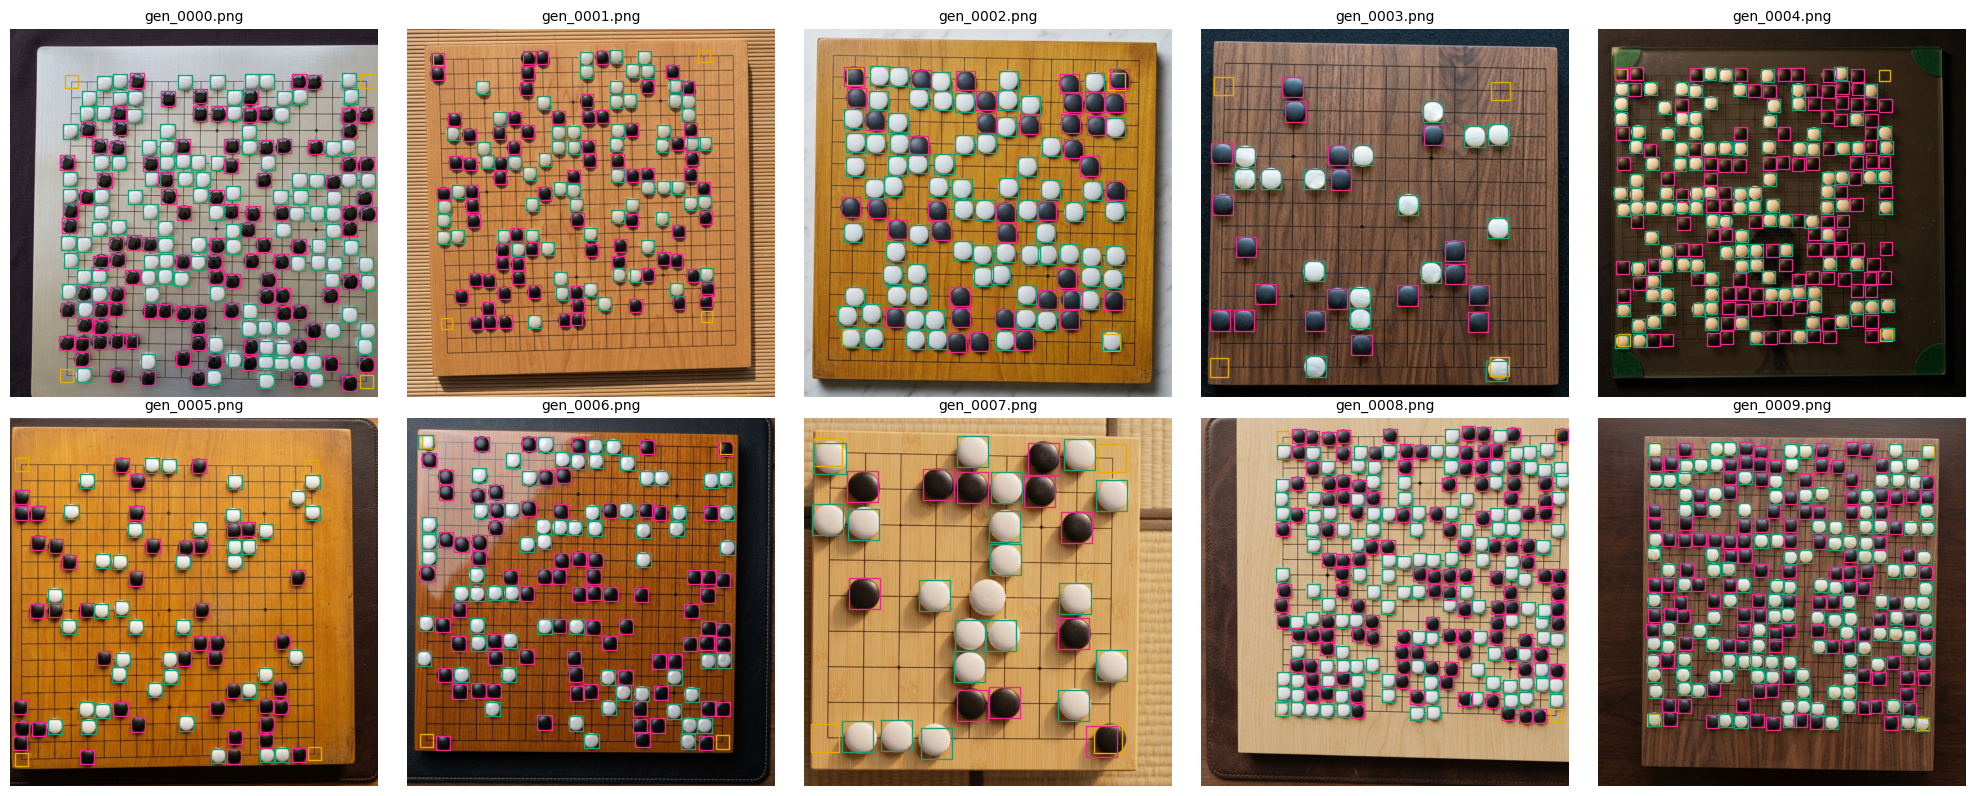

In [ ]:
import json

# Load annotations from per-image JSON files
annotations = {}
image_metas = []
for jf in sorted(IMAGES_DIR.glob("*.json")):
    with open(jf) as f:
        ann_data = json.load(f)
    img_meta = ann_data["image"]
    image_metas.append(img_meta)
    annotations[img_meta["filename"]] = {"boxes": ann_data["boxes"]}

n_boxes = sum(len(a["boxes"]) for a in annotations.values())
print(f"Images: {len(image_metas)}")
print(f"Total boxes: {n_boxes}")

# Display grid of generated images with annotation overlay
paths = sorted(IMAGES_DIR.glob("*.png"))[:20]
if paths:
    n = len(paths)
    cols = min(5, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes_flat = [axes] if n == 1 else axes.flat
    for ax, p in zip(axes_flat, paths):
        ax.imshow(Image.open(p))
        # Overlay annotations if available
        if p.name in annotations:
            for box in annotations[p.name]["boxes"]:
                color = CATEGORY_COLORS[box["category"]]
                rect = patches.Rectangle(
                    (box["x"], box["y"]), box["w"], box["h"],
                    linewidth=1, edgecolor=color, facecolor="none",
                )
                ax.add_patch(rect)
        ax.set_title(p.name, fontsize=10)
        ax.axis("off")
    for ax in list(axes_flat)[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No images generated yet.")

## Cost Estimate

| Model | Cost/image | 100 images | 500 images | 1000 images |
|-------|-----------|------------|------------|-------------|
| **Gemini 3.1 Flash Image** | **$0.067** | **$6.70** | **$33.50** | **$67** |

**Note**: Image-to-image (style transfer) costs the same as text-to-image
with Gemini. The synthetic annotation is free — no pseudo-labeling or
manual correction needed (just a quick verification pass with the annotator).